In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

In [3]:
ROOT = Path.cwd().parent
DATA_PATH = ROOT / 'data'

DATA_PATH



PosixPath('/Users/romacarapetean/Desktop/Projects/University/MLPC2026/data')

In [4]:
npz_path = DATA_PATH / 'audio_features' / '000078.npz'

# Extract a single npz file and print its contents
with np.load(npz_path, allow_pickle=True) as data:
    print(f"File: {npz_path.name}")
    print(f"Keys ({len(data.files)}): {data.files}\n")
    for key in data.files:
        value = data[key]
        print(f"{key}:")
        print(f"  shape={value.shape}, dtype={value.dtype}")
        if value.size <= 10:
            print(f"  values={value}")
        else:
            flat = value.ravel()
            print(f"  first 10 values={flat[:10]}")
        print()

File: 000078.npz
Keys (68): ['zcr_mean', 'zcr_std', 'zcr_min', 'zcr_max', 'start_time', 'end_time', 'melspect_mean', 'melspect_std', 'melspect_min', 'melspect_max', 'mfcc_mean', 'mfcc_std', 'mfcc_min', 'mfcc_max', 'mfcc_d_mean', 'mfcc_d_std', 'mfcc_d_min', 'mfcc_d_max', 'mfcc_d2_mean', 'mfcc_d2_std', 'mfcc_d2_min', 'mfcc_d2_max', 'flux_mean', 'flux_std', 'flux_min', 'flux_max', 'flatness_mean', 'flatness_std', 'flatness_min', 'flatness_max', 'centroid_mean', 'centroid_std', 'centroid_min', 'centroid_max', 'bandwidth_mean', 'bandwidth_std', 'bandwidth_min', 'bandwidth_max', 'contrast_mean', 'contrast_std', 'contrast_min', 'contrast_max', 'rolloff_low_mean', 'rolloff_low_std', 'rolloff_low_min', 'rolloff_low_max', 'rolloff_high_mean', 'rolloff_high_std', 'rolloff_high_min', 'rolloff_high_max', 'energy_mean', 'energy_std', 'energy_min', 'energy_max', 'power_mean', 'power_std', 'power_min', 'power_max', 'annotations', 'is_own_recording', 'class_names', 'annotator_ids', 'target_classes', 'n

In [5]:
feature_dir = Path.cwd().parent / "data" / "audio_features"
npz_files = sorted(feature_dir.glob("*.npz"))

exclude_keys = {
    "start_time", "end_time", "annotations", "is_own_recording",
    "class_names", "annotator_ids", "target_classes", "non_target_classes",
    "recording_device", "recording_environments", "scene_description",
    "device_placement"
}

all_values = {}

for file in npz_files:
    with np.load(file, allow_pickle=True) as data:
        for key in data.files:
            if key in exclude_keys:
                continue
            
            arr = data[key]
            if not np.issubdtype(arr.dtype, np.number):
                continue

            all_values.setdefault(key, []).append(arr.astype(float).ravel())

summary_rows = []

for key, chunks in all_values.items():
    values = np.concatenate(chunks)
    summary_rows.append({
        "feature": key,
        "mean": values.mean(),
        "std": values.std(),
        "min": values.min(),
        "max": values.max(),
        "range": values.max() - values.min()
    })

feature_summary = pd.DataFrame(summary_rows).sort_values("feature")
feature_summary.round(4)


,feature,mean,std,min,max,range
35,bandwidth_max,3404.2932,501.8532,0.0000,4951.6614,4951.6614
32,bandwidth_mean,2784.8472,518.9174,0.0000,4359.9744,4359.9744
34,bandwidth_min,2119.9490,642.8652,0.0000,3944.7943,3944.7943
33,bandwidth_std,289.6583,175.7630,0.0000,1872.7530,1872.7530
31,centroid_max,3355.2763,1072.7912,0.0000,7615.9776,7615.9776
28,centroid_mean,2207.0094,884.1986,0.0000,5788.9517,5788.9517
30,centroid_min,1354.6654,828.6408,0.0000,5129.3805,5129.3805
29,centroid_std,450.2543,259.6398,0.0000,2641.4163,2641.4163
39,contrast_max,27.0520,11.5389,3.3587,80.1071,76.7484
36,contrast_mean,15.7409,11.1985,2.5131,67.3213,64.8082


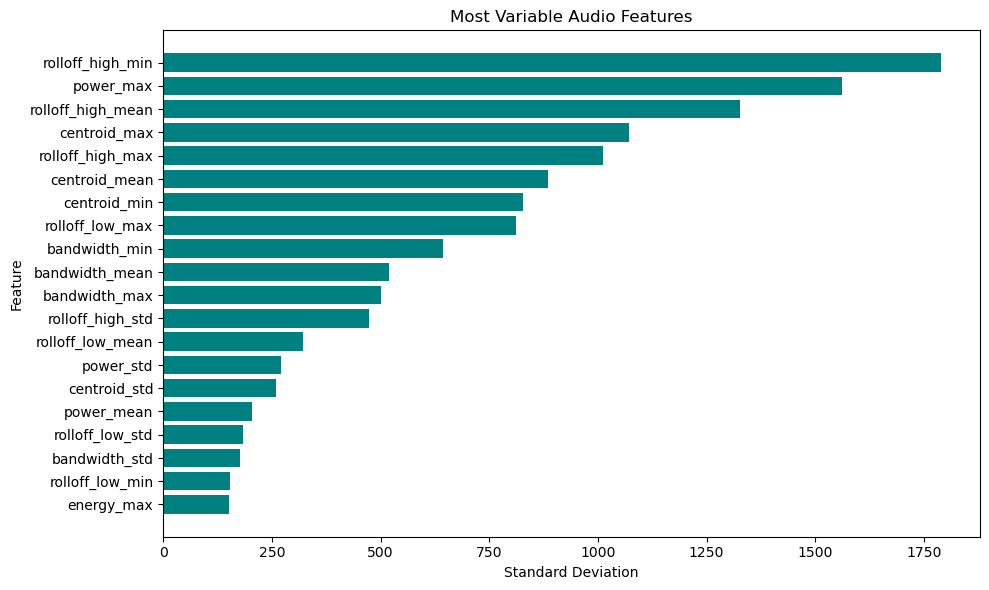

In [10]:
import matplotlib.pyplot as plt

plot_df = feature_summary.sort_values("std", ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"], plot_df["std"], color="teal")
plt.xlabel("Standard Deviation")
plt.ylabel("Feature")
plt.title("Most Variable Audio Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [7]:
data["zcr_mean"].shape

AttributeError: 'NoneType' object has no attribute 'open'